# LAB SHEET - 07

NAME - Saurabh Kumar Jha

Sec - B, CUid- CU24250005, Roll.No. 53

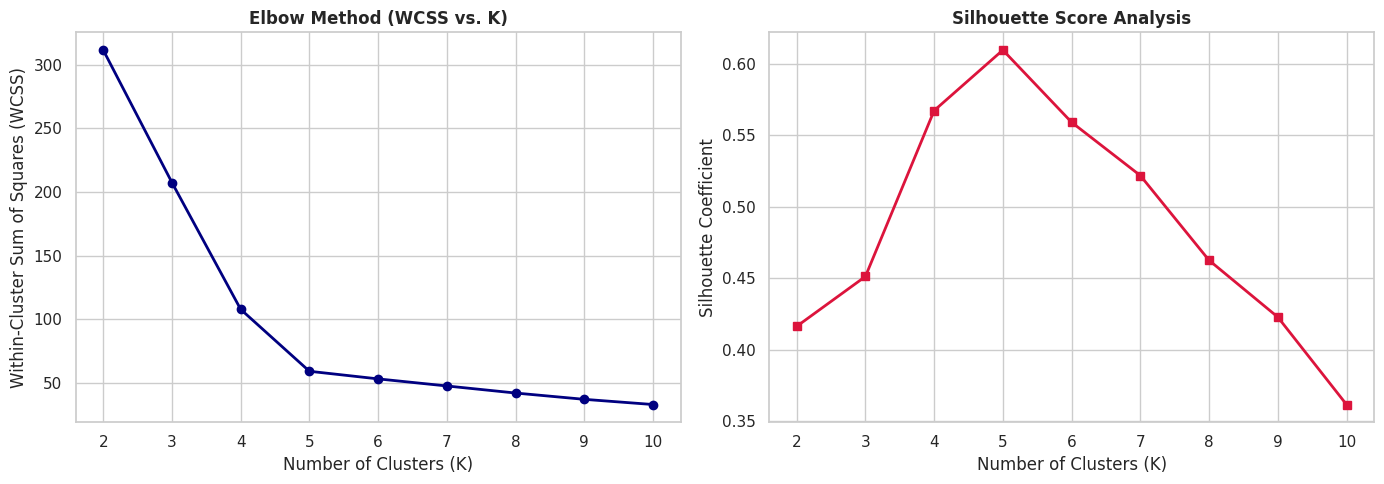

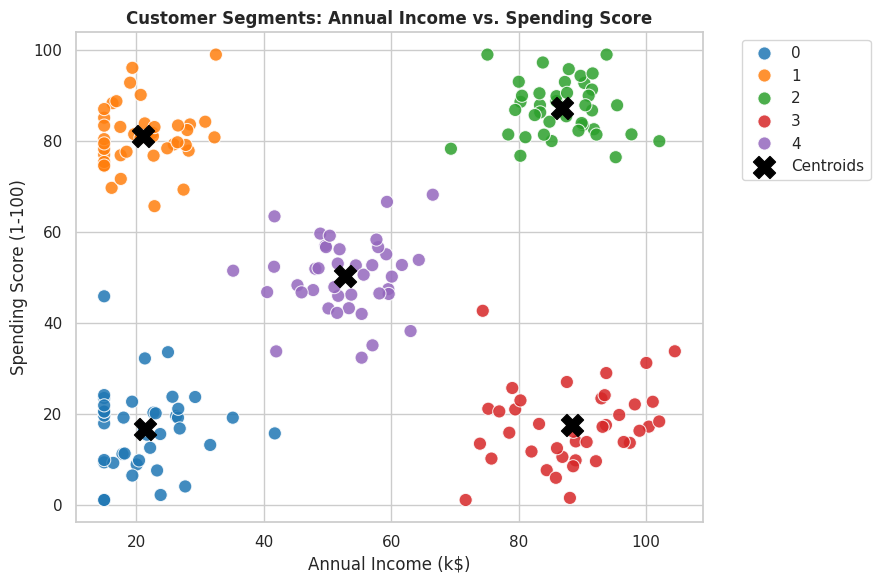

=== Customer Segment Demographic Profiles ===
 Cluster    Age  Annual_Income_k  Spending_Score
       0 44.350         21.39600        16.59400
       1 23.575         21.12375        81.03825
       2 31.000         86.75725        87.18625
       3 52.575         88.42950        17.39725
       4 38.700         52.83025        50.21425


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Step 1-3: Dataset Generation & Preprocessing
def generate_customer_dataset(sample_count: int = 200) -> pd.DataFrame:
    cluster_centers = [
        (25, 20, 81),  # Low Income, High Spending
        (45, 20, 15),  # Low Income, Low Spending
        (32, 85, 88),  # High Income, High Spending
        (52, 88, 18),  # High Income, Low Spending
        (40, 55, 50)   # Moderate Income, Moderate Spending
    ]
    records_per_cluster = sample_count // len(cluster_centers)
    customer_records = []

    for cluster_id, (age_mean, income_mean, spending_mean) in enumerate(cluster_centers):
        age_samples = np.clip(np.random.normal(age_mean, 5, records_per_cluster), 18, 70)
        income_samples = np.clip(np.random.normal(income_mean, 8, records_per_cluster), 15, 137)
        spending_samples = np.clip(np.random.normal(spending_mean, 8, records_per_cluster), 1, 99)

        for index in range(records_per_cluster):
            customer_records.append({
                'CustomerID': len(customer_records) + 1,
                'Age': int(age_samples[index]),
                'Annual_Income_k': round(float(income_samples[index]), 2),
                'Spending_Score': round(float(spending_samples[index]), 2)
            })
    return pd.DataFrame(customer_records)

customer_df = generate_customer_dataset(200)

selected_features = ['Age', 'Annual_Income_k', 'Spending_Score']
feature_matrix = customer_df[selected_features].values

# Step 4: Feature Standardization
feature_scaler = StandardScaler()
scaled_feature_matrix = feature_scaler.fit_transform(feature_matrix)

# Step 5: Optimal Cluster Determination (Elbow & Silhouette)
wcss_scores = []
silhouette_coefficients = []
k_range = range(2, 11)

for cluster_count in k_range:
    kmeans_model = KMeans(n_clusters=cluster_count, init='k-means++', n_init=10, random_state=42)
    kmeans_model.fit(scaled_feature_matrix)
    wcss_scores.append(kmeans_model.inertia_)
    silhouette_coefficients.append(silhouette_score(scaled_feature_matrix, kmeans_model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss_scores, marker='o', color='navy', linewidth=2)
axes[0].set_title('Elbow Method (WCSS vs. K)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')

axes[1].plot(k_range, silhouette_coefficients, marker='s', color='crimson', linewidth=2)
axes[1].set_title('Silhouette Score Analysis', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Coefficient')

plt.tight_layout()
plt.show()

# Step 6 & 7: Model Training & Visualization
optimal_k = 5
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
customer_df['Cluster'] = final_kmeans.fit_predict(scaled_feature_matrix)

# Unscale centroids for interpretation
scaled_centroids = final_kmeans.cluster_centers_
unscaled_centroids = feature_scaler.inverse_transform(scaled_centroids)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=customer_df, x='Annual_Income_k', y='Spending_Score',
    hue='Cluster', palette='tab10', s=90, alpha=0.85
)
plt.scatter(
    unscaled_centroids[:, 1], unscaled_centroids[:, 2],
    s=250, c='black', marker='X', label='Centroids'
)
plt.title('Customer Segments: Annual Income vs. Spending Score', fontsize=12, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Step 8–10: Segment Profiles
cluster_profiles = customer_df.groupby('Cluster')[selected_features].mean().reset_index()
print("=== Customer Segment Demographic Profiles ===")
print(cluster_profiles.to_string(index=False))



### Questions and Answers

**1. What is clustering? How does it differ from classification?**

* **Clustering:** An unsupervised learning technique that groups unlabeled data instances based on spatial proximity or feature similarities without target labels.


* **Classification:** A supervised learning technique that trains algorithms on labeled training instances to assign new observations into predefined discrete target categories.

**2. Explain the working principle of the K-Means Clustering algorithm.**

* K-Means partitions $N$ observations into $K$ distinct clusters by minimizing the within-cluster sum of squares (WCSS).


* It initializes $K$ centroids, assigns each observation to its closest centroid using Euclidean distance, recomputes each centroid as the mean of its assigned cluster points, and iterates until convergence.



**3. Why is feature scaling important before applying K-Means clustering?**

* K-Means relies directly on distance calculations (such as Euclidean distance) to compute cluster assignments.


* Unscaled features with large numerical ranges (e.g., Annual Income in thousands) artificially dominate distance metrics compared to features measured on smaller scales (e.g., Age).



**4. What is the Elbow Method, and how does it help determine the optimal number of clusters?**

* The Elbow Method plots $K$ against the Within-Cluster Sum of Squares (WCSS).


* As $K$ increases, WCSS decreases monotonically; the point where the rate of decrease abruptly shifts ("elbow point") signifies the optimal number of clusters where adding more clusters yields diminishing variance reduction.



**5. What is the Silhouette Score? How is it used to evaluate clustering performance?**

* The Silhouette Score evaluates cluster cohesion and separation for each sample $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$



where $a(i)$ is mean intra-cluster distance and $b(i)$ is mean nearest-cluster distance.
* Values range from $-1$ (poor/misclustered) to $+1$ (dense, well-separated clusters).



**6. Why is K-Means considered an unsupervised machine learning algorithm?**

* K-Means operates on unlabeled datasets without requiring predefined ground-truth outcome categories or historical supervisor feedback during training.



**7. Mention any four real-world applications of customer segmentation.**

* Targeted e-commerce email marketing campaigns.
* Dynamic churn prevention and loyalty reward program structuring.
* Credit card risk tiering and customized lending offerings.
* Retail store layout optimization based on local shopper demographic profiles.

**8. What are the limitations of the K-Means algorithm?**

* Requires setting $K$ manually in advance.


* Sensitive to initial centroid placement and vulnerable to local minima.


* Assumes spherical, equal-sized clusters and struggles with non-globular or complex geometric boundaries.


* Sensitive to extreme outliers, which distort cluster centroid calculation.



**9. How can businesses use customer segmentation to improve marketing and customer retention?**

* High-income/high-spending segments receive premium product promotions and exclusive rewards.
* High-income/low-spending segments receive personalized incentive discounts to boost engagement.
* Low-income/high-spending segments receive budget-conscious promotional offers to maintain brand engagement without overextending credit risks.

**10. Compare K-Means Clustering with Hierarchical Clustering based on their working principles and applications.**

| Feature | K-Means Clustering | Hierarchical Clustering |
| --- | --- | --- |
| **Working Principle** | Centroid-based partitioning algorithm that minimizes intra-cluster distance iteratively.| Tree-based aggregation (agglomerative) or division (divisive) creating nested cluster trees (dendrograms).|
| **Cluster Number ($K$)** | Must be specified beforehand ($K$).| Determined after inspecting the dendrogram structure.|
| **Scalability** | Computationally efficient $O(N \cdot K \cdot I)$ suitable for large datasets.| $O(N^3)$ time complexity, computationally expensive for large datasets.|
| **Best Used For** | Large-scale production datasets with well-separated globular clusters.| Taxonomy building, gene sequencing, and small datasets requiring hierarchical visual inspection.|

---
